# Analise exploratoria


In [38]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
conn = sqlite3.connect('/workspaces/moneyball-brasileirao/databases/brasileirao.db')

In [32]:
query = '''
    SELECT i.clube, i.valor_inicio, i.numero_jogadores_inicio,
    f.valor_final, f.numero_jogadores_final,
    g.media_idade, g.estrangeiros, g.media_valor_mercado_,
    c.rowid AS posicao_final
    FROM inicio_ano as i
    JOIN fim_ano as f ON i.clube = f.clube
    JOIN geral as g ON i.clube = g.clube
    JOIN classificacao_final as c ON i.clube = c.clube
    ORDER BY c.rowid, i.valor_inicio, i.clube  DESC
'''

In [33]:
query_master = '''SELECT * FROM master'''

In [ ]:
df = pd.read_sql_query(query, conn)

In [50]:
df[['valor_inicio', 'media_idade', 'estrangeiros', 'posicao_final']].describe()

,valor_inicio,media_idade,estrangeiros,posicao_final
count,20.000000,20.000000,20.000000,20.00000
mean,82.211000,23.745000,9.900000,10.50000
std,61.949763,1.384681,4.063962,5.91608
min,7.730000,21.900000,0.000000,1.00000
25%,45.307500,22.975000,6.750000,5.75000
50%,80.900000,23.350000,11.000000,10.50000
75%,88.362500,24.150000,12.000000,15.25000
max,227.880000,27.200000,17.000000,20.00000


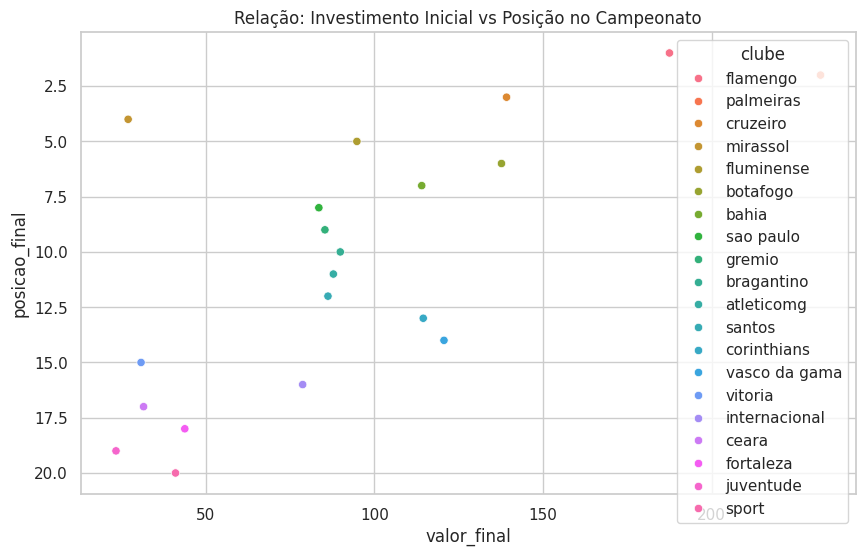

In [52]:
def scatter_investimento_posicao(df):        
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='valor_final', y='posicao_final', hue='clube')
    plt.gca().invert_yaxis() 
    plt.title('Relação: Investimento Inicial vs Posição no Campeonato')
    plt.grid(True)
    plt.show()
scatter_investimento_posicao(df)

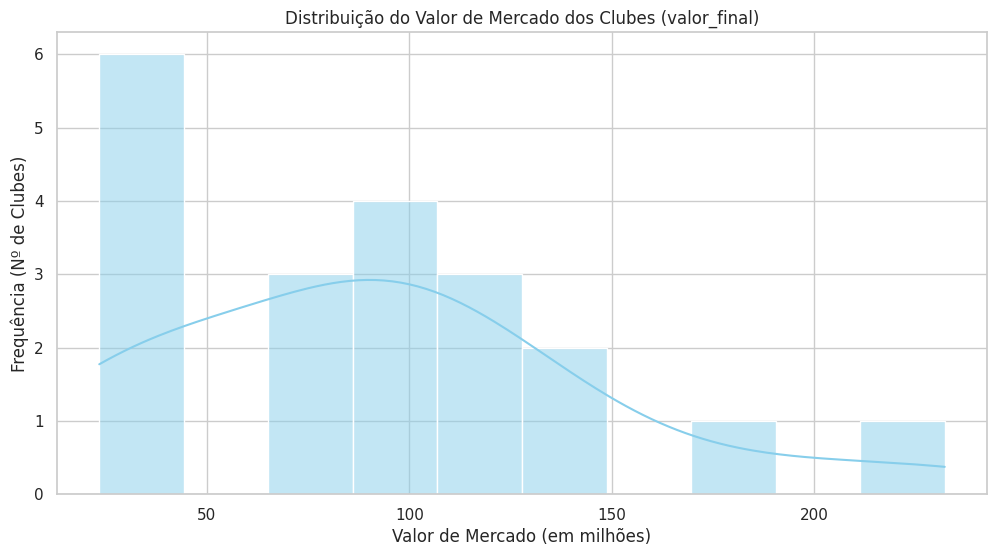

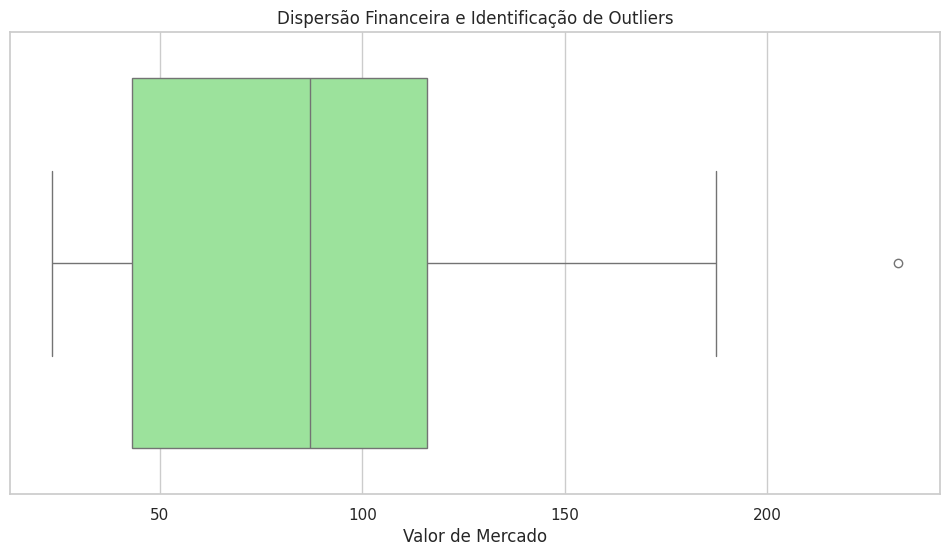

/tmp/ipykernel_19766/1960262533.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.sort_values('media_idade'), x='clube', y='media_idade', palette='viridis')


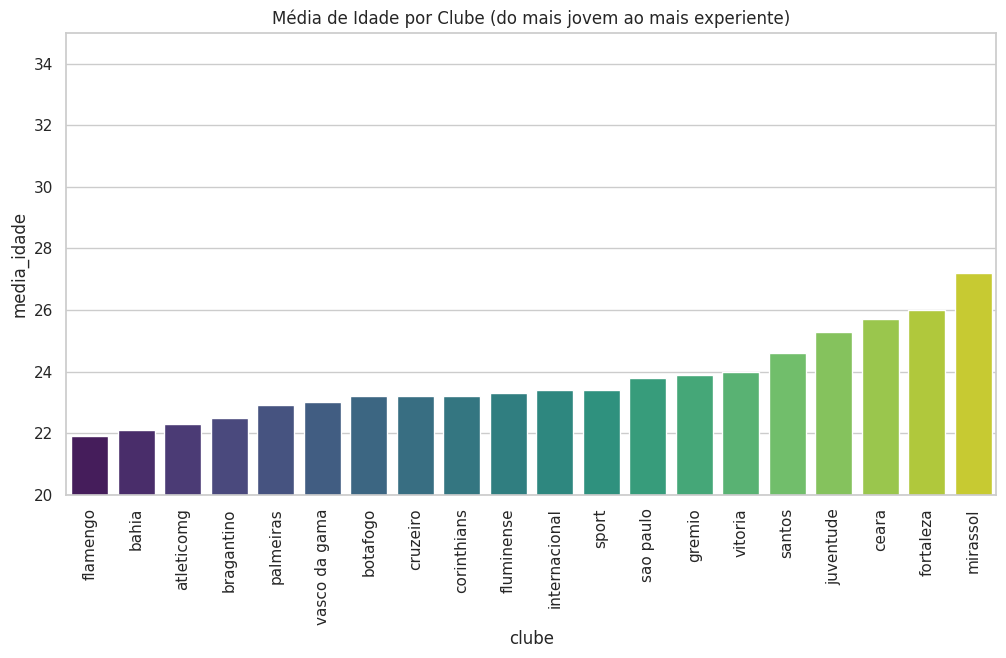

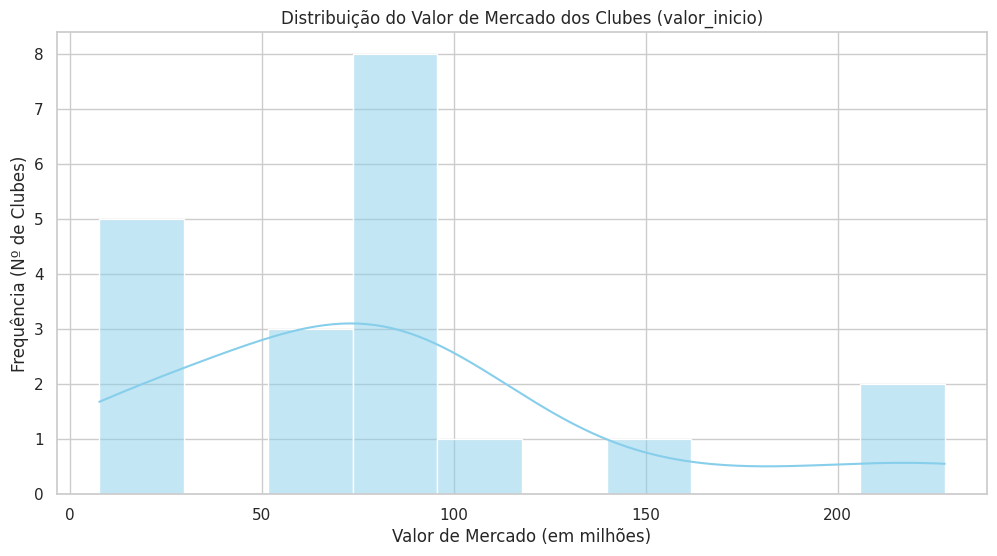

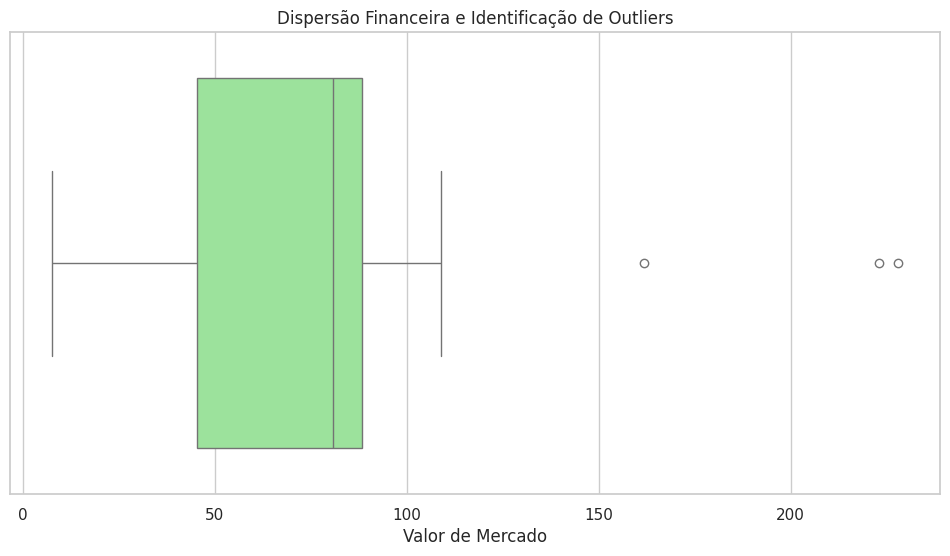

/tmp/ipykernel_19766/1960262533.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.sort_values('media_idade'), x='clube', y='media_idade', palette='viridis')


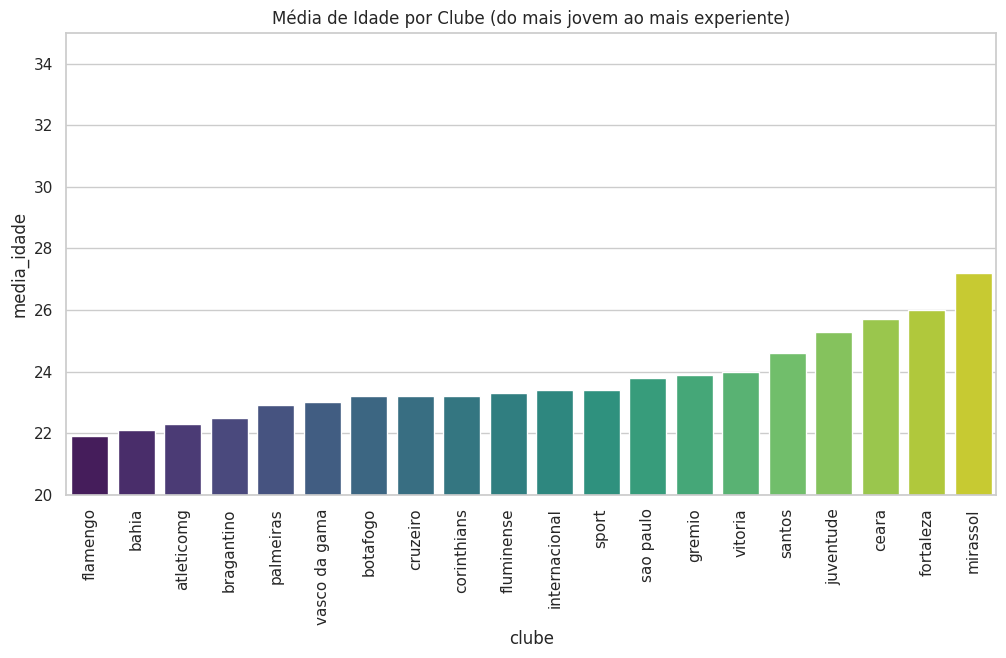

In [55]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

def univariadas(df, coluna):
    # 1. Distribuição do Valor de Mercado (Início do Ano)
    plt.figure()
    sns.histplot(df[coluna], kde=True, color='skyblue', bins=10)
    plt.title(f'Distribuição do Valor de Mercado dos Clubes ({coluna})')
    plt.xlabel('Valor de Mercado (em milhões)')
    plt.ylabel('Frequência (Nº de Clubes)')
    plt.show()

    # 2. Boxplot para detectar Outliers Financeiros
    plt.figure()
    sns.boxplot(x=df[coluna], color='lightgreen')
    plt.title('Dispersão Financeira e Identificação de Outliers')
    plt.xlabel('Valor de Mercado')
    plt.show()

    # 3. Perfil de Idade Média
    plt.figure()
    sns.barplot(data=df.sort_values('media_idade'), x='clube', y='media_idade', palette='viridis')
    plt.xticks(rotation=90)
    plt.title('Média de Idade por Clube (do mais jovem ao mais experiente)')
    plt.ylim(20, 35) 
    plt.show()

univariadas(df, 'valor_final')
univariadas(df, 'valor_inicio')

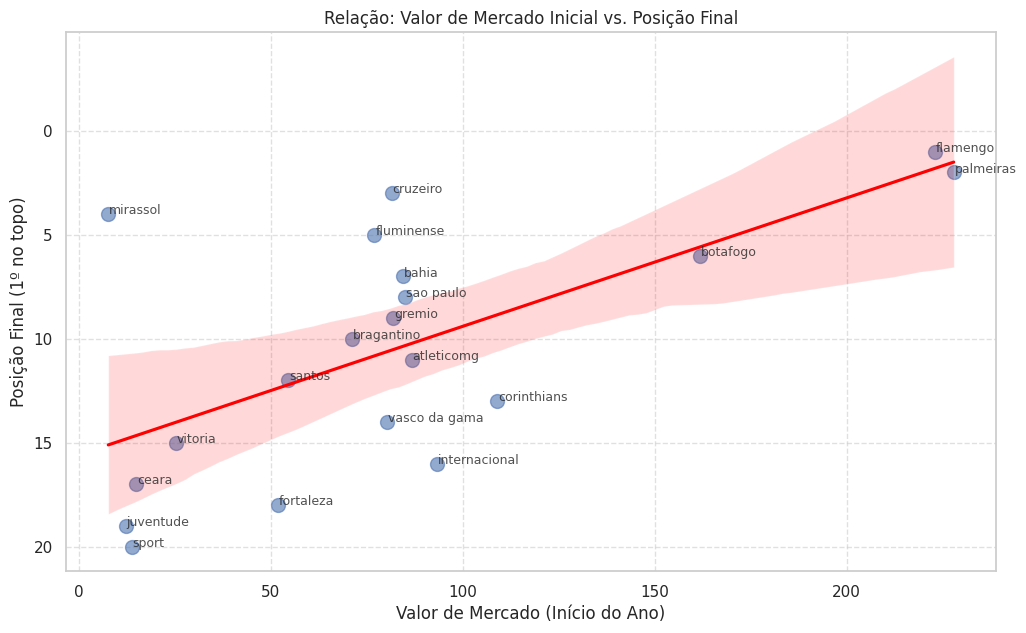

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

def bivariada(df):
    # 1. Valor Inicial vs Posição Final com Linha de Regressão
    plt.figure(figsize=(12, 7))
    sns.regplot(data=df, x='valor_inicio', y='posicao_final', 
                scatter_kws={'s': 100, 'alpha': 0.6}, line_kws={'color': 'red'})
    
    # Adicionar nomes dos clubes aos pontos para identificar os "Eficientes"
    for i in range(df.shape[0]):
        plt.text(df.valor_inicio[i]+0.2, df.posicao_final[i], 
                 df.clube[i], fontsize=9, alpha=0.8)

    plt.gca().invert_yaxis() # Inverte o eixo Y: 1º lugar no topo
    plt.title('Relação: Valor de Mercado Inicial vs. Posição Final')
    plt.xlabel('Valor de Mercado (Início do Ano)')
    plt.ylabel('Posição Final (1º no topo)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

bivariada(df)

/tmp/ipykernel_19766/583684136.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.sort_values('posicao_final'),


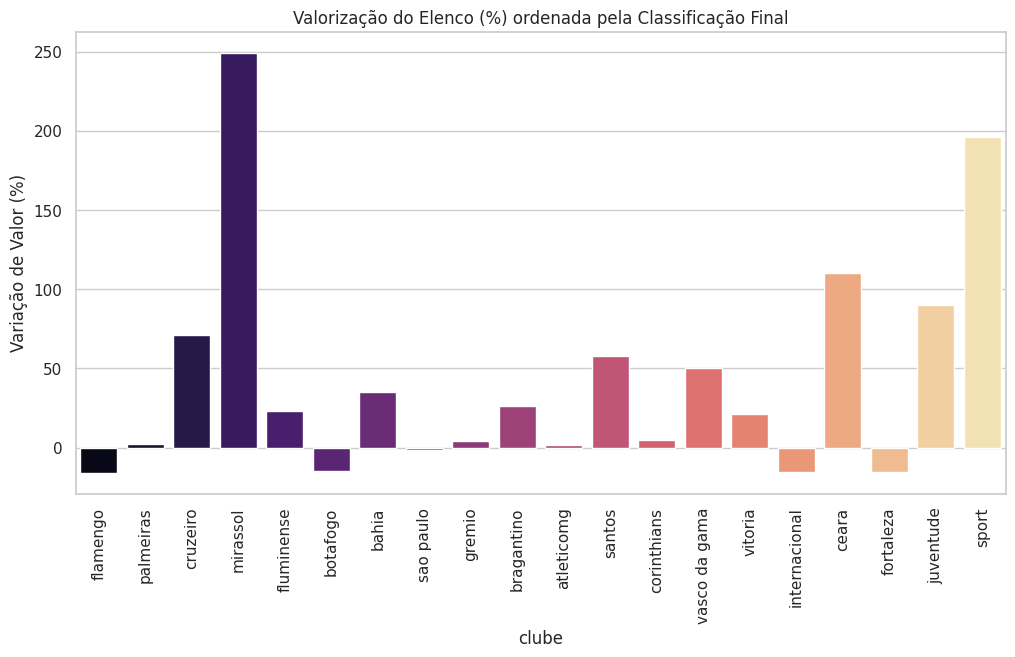

In [65]:
# Criando a métrica de valorização
df['valorizacao_percentual'] = ((df['valor_final'] - df['valor_inicio']) / df['valor_inicio']) * 100

plt.figure(figsize=(12, 6))
sns.barplot(data=df.sort_values('posicao_final'), 
            x='clube', y='valorizacao_percentual', palette='magma')
plt.xticks(rotation=90)
plt.title('Valorização do Elenco (%) ordenada pela Classificação Final')
plt.ylabel('Variação de Valor (%)')
plt.show()

In [63]:
correlacao = df['valor_final'].corr(df['posicao_final'])
print(f"Coeficiente de Correlação de Pearson: {correlacao:.2f}")

Coeficiente de Correlação de Pearson: -0.70


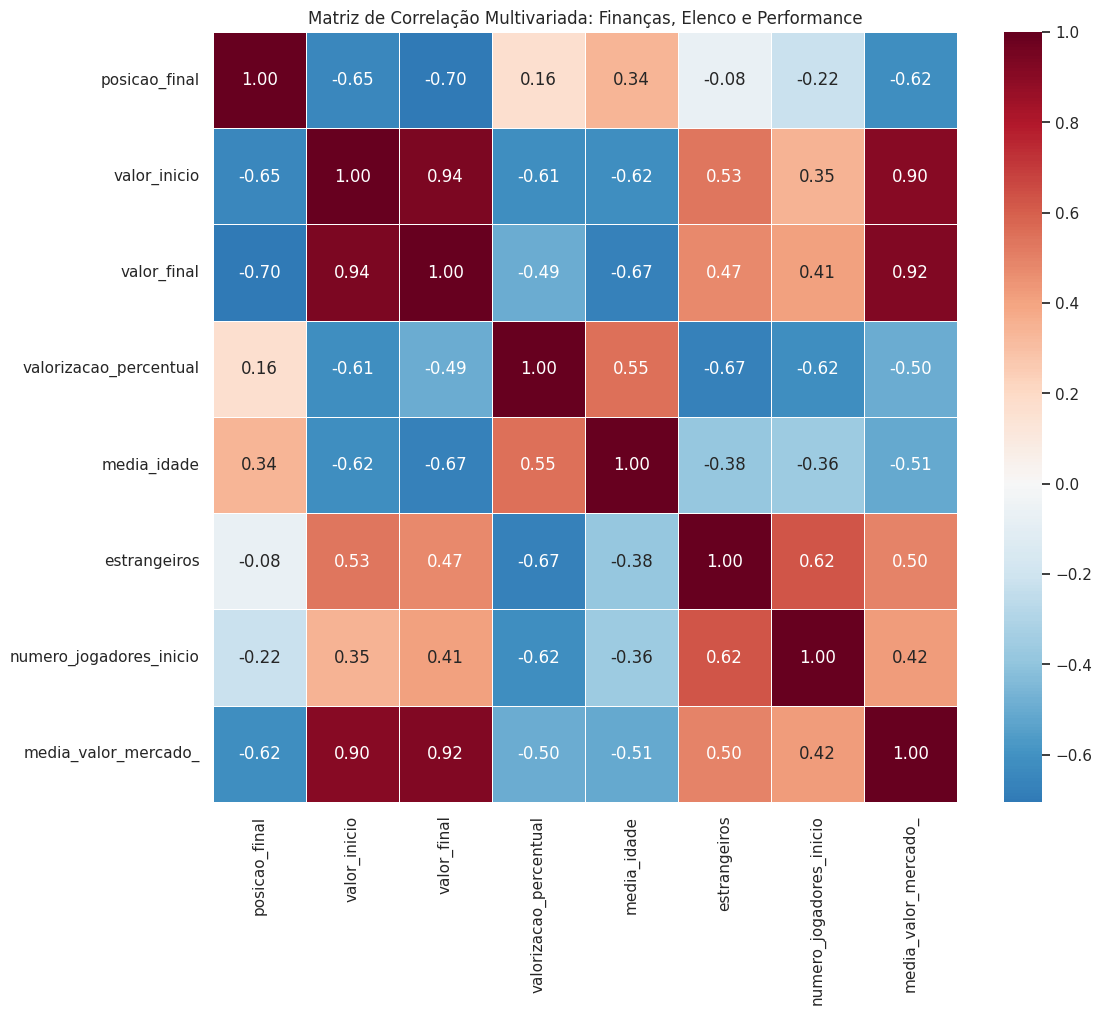

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def analise_corr(df):
    colunas_analise = [
        'posicao_final', 'valor_inicio', 'valor_final', 
        'valorizacao_percentual', 'media_idade', 'estrangeiros',
        'numero_jogadores_inicio', 'media_valor_mercado_'
    ]
    
    df_corr = df[colunas_analise].corr()

    # 2. Criar o Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(df_corr, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=0.5)
    plt.title('Matriz de Correlação Multivariada: Finanças, Elenco e Performance')
    plt.show()

analise_corr(df)

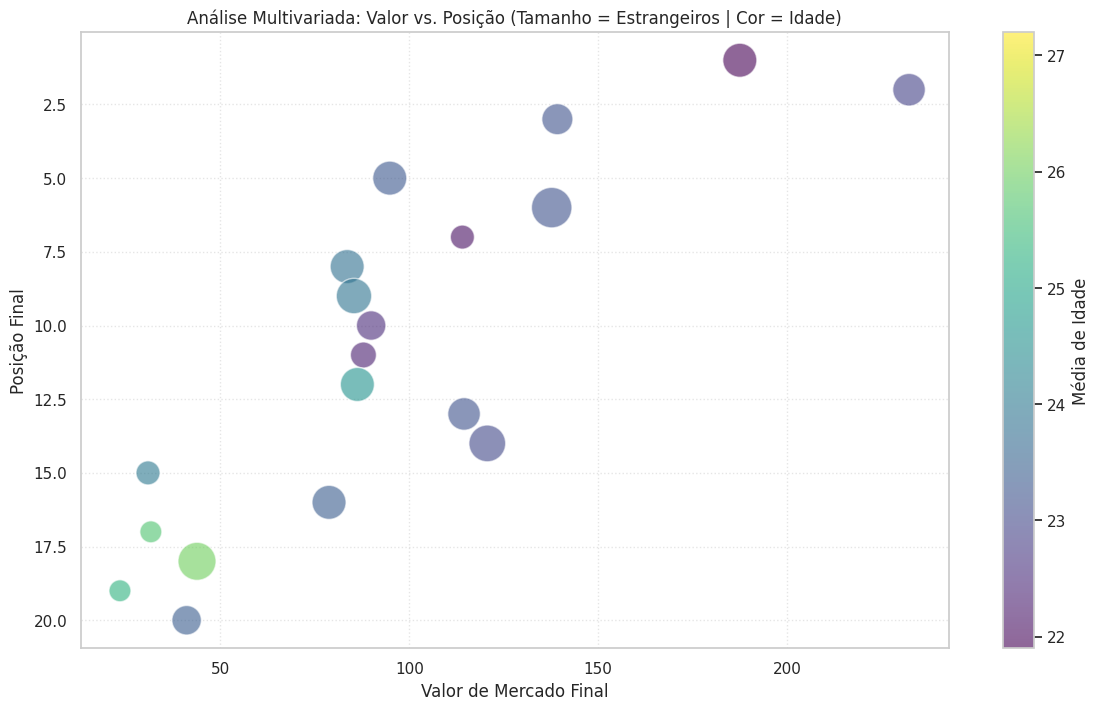

In [62]:
plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    df['valor_final'], 
    df['posicao_final'], 
    s=df['estrangeiros'] * 50, # Tamanho pela qtde de estrangeiros
    c=df['media_idade'],       # Cor pela idade média
    cmap='viridis', 
    alpha=0.6, 
    edgecolors="w"
)

# Inverter eixo Y para 1º lugar ficar no topo
plt.gca().invert_yaxis()

# Adicionar barra de cores para Idade
cbar = plt.colorbar(scatter)
cbar.set_label('Média de Idade')

# Legendas
plt.title('Análise Multivariada: Valor vs. Posição (Tamanho = Estrangeiros | Cor = Idade)')
plt.xlabel('Valor de Mercado Final')
plt.ylabel('Posição Final')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

In [70]:
# 1. Criar ranking de investimento (1 = mais caro, 20 = mais barato)
df['rank_valor'] = df['valor_final'].rank(ascending=False)

# 2. Calcular a Eficiência (Diferença entre Rank de Valor e Posição Real)
# Valores positivos = Superou as expectativas (Eficiente)
# Valores negativos = Abaixo das expectativas (Ineficiente)
df['indice_eficiencia'] = df['rank_valor'] - df['posicao_final']

# Visualizar os 5 mais eficientes
top_eficientes = df.sort_values('indice_eficiencia', ascending=False)
print("indice de eficiencia")
print(top_eficientes[['clube', 'posicao_final', 'indice_eficiencia']])

indice de eficiencia
            clube  posicao_final  indice_eficiencia
3        mirassol              4               15.0
7       sao paulo              8                5.0
4      fluminense              5                3.0
8          gremio              9                3.0
14        vitoria             15                3.0
18      juventude             19                1.0
0        flamengo              1                1.0
2        cruzeiro              3                0.0
6           bahia              7                0.0
16          ceara             17                0.0
1       palmeiras              2               -1.0
10     atleticomg             11               -1.0
9      bragantino             10               -1.0
11         santos             12               -1.0
5        botafogo              6               -2.0
15  internacional             16               -2.0
17      fortaleza             18               -3.0
19          sport             20           

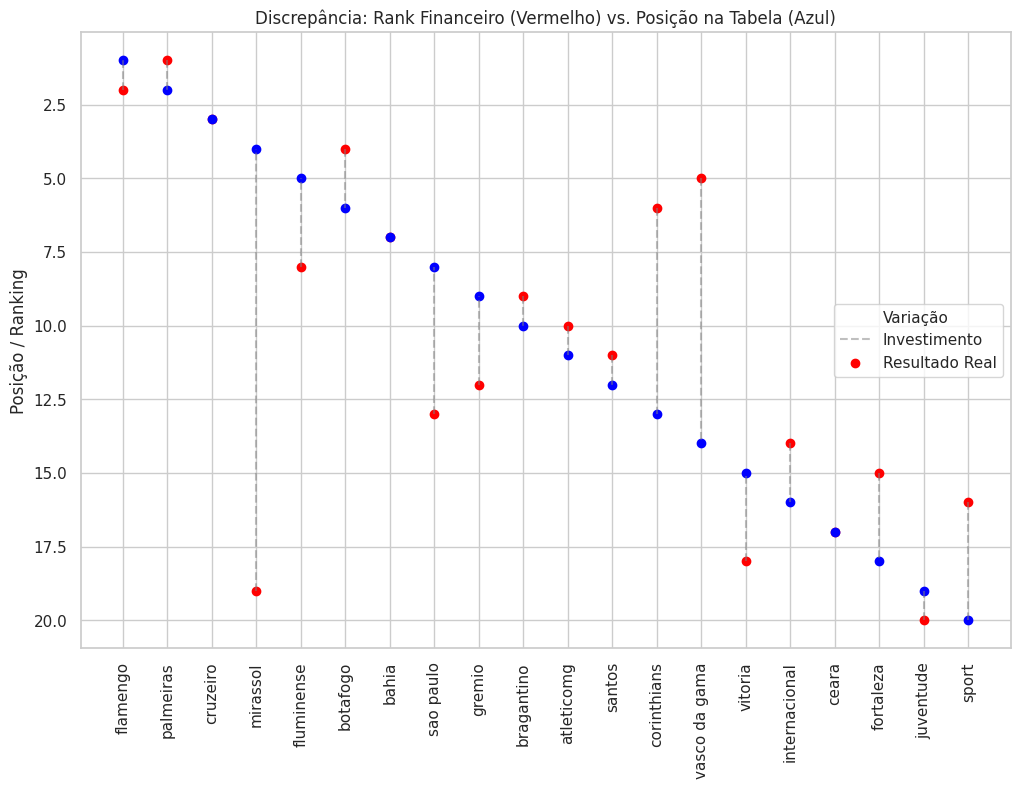

In [ ]:
plt.figure(figsize=(12, 8))
df_plot = df.sort_values('posicao_final')

plt.scatter(df_plot['clube'], [1]*len(df_plot), s=0) 
for i, row in df_plot.iterrows():
    plt.plot([row['clube'], row['clube']], [row['rank_valor'], row['posicao_final']], 
             color='gray', linestyle='--', alpha=0.5)
    plt.scatter(row['clube'], row['rank_valor'], color='red', label='Rank Financeiro' if i == 0 else "")
    plt.scatter(row['clube'], row['posicao_final'], color='blue', label='Posição Final' if i == 0 else "")

plt.gca().invert_yaxis()
plt.xticks(rotation=90)
plt.title('Discrepância: Rank Financeiro (Vermelho) vs. Posição na Tabela (Azul)')
plt.legend(['Variação', 'Investimento', 'Resultado Real'])
plt.ylabel('Posição / Ranking')
plt.show()